In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering

In [2]:
os.chdir(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base')
print(os.listdir())  # Muestra todos los archivos en el directorio actual

['df_normalizado.json', 'F00018221-Latinobarometro_2024_Argentina_Excel_eng_v1.xlsx']


Punto 1

In [3]:
# Cargo las bases de datos
df_Arg=pd.read_excel(r'C:\Users\juanc\OneDrive\Desktop\Big data y Machine learning\TRABAJOS PRACTICOS\Exposicion\Parte1\Base\F00018221-Latinobarometro_2024_Argentina_Excel_eng_v1.xlsx')


c:\Users\juanc\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
df_Arg

,NUMINVES: Año del estudio,IDENPA: País,NUMENTRE: Número de Entrevista,REG: Región/ Provincia,CIUDAD: Ciudad,TAMCIUD: Tamaño de hábitat,COMDIST: Denominación muestral: Sector/Municipio/Comuna/Barrio/Distrito,EDAD: Edad,SEXO: Sexo,CODIGO: Código de encuestador,...,S23: Tipo de trabajo que realiza el jefe de familia,S24: Apreciación nivel socioeconómico (realizado por el encuestador),S25: Apreciación de la condición de la entrevista,REEDUC.1: Nivel de estudios alcanzado - Entrevistado (recodificado),REEDUC.2: Nivel de estudios alcanzado - Padres (Recodificado),REEDUC.3: Nivel de estudios alcanzado - Jefe de familia (Recodificado),REEDAD: EDAD RECODIFICADA,PERPART: Participación en gobierno del partido político al que vota,FAMPART: Familia Partido Político,WT: Ponderación
0,24,32,1,32002,32301000,8,1,83,2,33,...,8,2,1,2,2,5,4,4,0,1.5921
1,24,32,2,32002,32301000,8,1,30,2,33,...,-3,2,1,6,7,-3,2,4,0,0.9648
2,24,32,3,32002,32301000,8,1,59,1,33,...,8,2,1,5,2,6,3,4,0,0.7200
3,24,32,4,32002,32301000,8,1,62,1,33,...,-3,1,1,6,4,-3,4,2,30,0.9648
4,24,32,5,32002,32301000,8,1,46,2,33,...,2,2,1,5,3,5,3,4,0,0.7200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1205,24,32,1206,32901,32301966,2,177,43,1,66,...,5,2,1,5,4,7,3,4,0,0.7200
1206,24,32,1207,32901,32301966,2,177,43,2,66,...,-3,2,1,5,5,-3,3,4,0,0.7200
1207,24,32,1208,32901,32301966,2,177,68,1,66,...,-3,2,1,4,2,-3,4,4,0,0.7200
1208,24,32,1209,32901,32301966,2,177,40,1,66,...,-3,2,1,5,5,-3,2,1,40,0.7200


In [5]:
df_Arg.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 332 columns):
 #    Column                                                                                                                                                              Dtype  
---   ------                                                                                                                                                              -----  
 0    NUMINVES: Año del estudio                                                                                                                                           int64  
 1    IDENPA: País                                                                                                                                                        int64  
 2    NUMENTRE: Número de Entrevista                                                                                                                                      int64  
 3

Analizamos que variables nos interesan

In [6]:
df_Arg.columns

Index(['NUMINVES: Año del estudio', 'IDENPA: País',
       'NUMENTRE: Número de Entrevista', 'REG: Región/ Provincia',
       'CIUDAD: Ciudad', 'TAMCIUD: Tamaño de hábitat',
       'COMDIST: Denominación muestral: Sector/Municipio/Comuna/Barrio/Distrito',
       'EDAD: Edad', 'SEXO: Sexo', 'CODIGO: Código de encuestador',
       ...
       'S23: Tipo de trabajo que realiza el jefe de familia',
       'S24: Apreciación nivel socioeconómico (realizado por el encuestador)',
       'S25: Apreciación de la condición de la entrevista',
       'REEDUC.1: Nivel de estudios alcanzado - Entrevistado (recodificado)',
       'REEDUC.2: Nivel de estudios alcanzado - Padres (Recodificado)',
       'REEDUC.3: Nivel de estudios alcanzado - Jefe de familia (Recodificado)',
       'REEDAD: EDAD RECODIFICADA',
       'PERPART: Participación en gobierno del partido político al que vota',
       'FAMPART: Familia Partido Político', 'WT: Ponderación'],
      dtype='object', length=332)

In [33]:
# =============================================================================
# 1. SELECCIÓN Y PREPARACIÓN DE DATOS (CORREGIDO)
# =============================================================================

def normalizar_nombres(df):
    """Normalizar nombres de columnas correctamente"""
    # Primero aplicar las transformaciones básicas
    df.columns = df.columns.str.upper().str.strip()
    
    # Reemplazar múltiples espacios y caracteres especiales por UN solo guión bajo
    df.columns = (
        df.columns
        .str.replace(r"\s+", "_", regex=True)  # Múltiples espacios por _
        .str.replace(r"[:\.\/\{\}]", "_", regex=True)  # Caracteres especiales por _
        .str.replace(r"_+", "_", regex=True)  # Múltiples _ por uno solo
        .str.strip("_")  # Remover _ al inicio/final
    )
    return df

# Lista de variables seleccionadas
vars_selected = [
    # Variables de identificación (3)
    "NUMINVES: Año del estudio",
    "IDENPA: País", 
    "REG: Región/ Provincia",
    
    # Actitudes políticas e instituciones (12)
    "P14ST.E: Confianza en el Gobierno",
    "P14ST.D: Confianza en el Congreso/Parlamento", 
    "P14ST.G: Confianza en los partidos políticos",
    "P14ST.F: Confianza en el Poder Judicial",
    "P14ST.A: Confianza en las Fuerzas Armadas",
    "P14ST.B: Confianza en la Policía",
    "P14ST.C: Confianza en la Iglesia",
    "P14ST.H: Confianza en la institución Electoral del país",
    "P12STGBS.A: Satisfacción con la democracia",
    "P11STGBS: Apoyo a la democracia",
    "P16ST: Autoubicación en escala Izquierda-Derecha",
    "P2ST: Imagen de progreso del país",
    "P13ST: {PAÍS} gobernado por unos cuantos grupos poderosos en su propio beneficio o para el bien de todo el pueblo",
    
    # Identidad política y participación (6)
    "P22N: No puede haber democracia sin oposición",
    "P23STM.1: Quién tiene más poder en {PAÍS} (Primera mención)",
    "P24STGBS: Frase mas cerca de su manera de pensar: La política es tan complicada que no se entiende o La política no es tan complicada y se entiende",
    "P25ST: Se siente políticamente representado por el parlamento/congreso",
    "P26ST: La manera como uno vota puede hacer que las cosas sean diferentes en el futuro",
    "P41ST: Frases más cerca de su manera de pensar",
    
    # Socioeconómicas y demográficas (6)
    "EDAD: Edad",
    "SEXO: Sexo",
    "P1ST: Grado de satisfacción con la vida", 
    "P39STGBS.A: Partido que votaría si este domingo hubiera elecciones.",
    "P6STGBS: Situación económica actual del país",
    "P7STGBS: Situación económica actual del país comparada con hace doce meses",
    "P9STGBS: Como será su situación económica y la de su familia dentro de doce meses",
    
    # Percepciones sociales y valores (6)
    "P4ST: Necesidad de mejora de la sociedad en que vivimos",
    "P5STGBS: Problema más importante en el país",
    "P8ST: Como será la situación económica del país dentro de doce meses",
    "P27ST: Las elecciones en este país son limpias o son fraudulentas",
    "P28ST: Cómo ve Ud. el futuro para la generación que viene, comparado con hoy, será más, igual o menos próspero.",
    "P29ST.A: Opinión sobre Estados Unidos"
]

print("=" * 60)
print("1. SELECCIÓN DE VARIABLES")
print("=" * 60)

# Filtrar columnas existentes
cols_matched = [col for col in vars_selected if col in df_Arg.columns]
cols_missing = [col for col in vars_selected if col not in df_Arg.columns]

print(f"✅ Columnas encontradas: {len(cols_matched)}/{len(vars_selected)}")
print(f"⚠️  Columnas faltantes: {len(cols_missing)}")

if cols_missing:
    print("\nColumnas que no se encontraron:")
    for col in cols_missing:
        print(f"  - {col}")

# Crear DataFrame seleccionado
df_selected = df_Arg[cols_matched].copy()
print(f"\n📊 DataFrame seleccionado: {df_selected.shape}")

# =============================================================================
# 2. NORMALIZACIÓN Y LIMPIEZA
# =============================================================================

print("\n" + "=" * 60)
print("2. NORMALIZACIÓN Y LIMPIEZA")
print("=" * 60)

# Aplicar normalización de nombres
df_normalizado = normalizar_nombres(df_selected)

print("✅ Nombres normalizados CORREGIDOS:")
print(df_normalizado.columns.tolist()[:15])  # Mostrar primeros 15

# Reemplazar códigos especiales por NaN
special_codes = [0, 8, 97, 98, 99]
df_normalizado.replace(special_codes, np.nan, inplace=True)

print(f"\n🧹 Códigos especiales {special_codes} reemplazados por NaN")

# =============================================================================
# 3. ANÁLISIS EXPLORATORIO INICIAL
# =============================================================================

print("\n" + "=" * 60)
print("3. ANÁLISIS EXPLORATORIO")
print("=" * 60)

# Información básica
if "NUMINVES_AÑO_DEL_ESTUDIO" in df_normalizado.columns:
    print(f"📅 Años del estudio: {df_normalizado['NUMINVES_AÑO_DEL_ESTUDIO'].unique()}")

if "IDENPA_PAÍS" in df_normalizado.columns:
    print(f"🌎 Países: {df_normalizado['IDENPA_PAÍS'].unique()}")

if "REG_REGIÓN_PROVINCIA" in df_normalizado.columns:
    print(f"🗺️  Número de regiones: {df_normalizado['REG_REGIÓN_PROVINCIA'].nunique()}")

# =============================================================================
# 4. VERIFICAR NOMBRES EXACTOS
# =============================================================================

print("\n" + "=" * 60)
print("4. BÚSQUEDA DE VARIABLES CLAVE")
print("=" * 60)

# Buscar patrones en los nombres reales
vars_clave_patrones = [
    "CONFIANZA_EN_EL_GOBIERNO",
    "SITUACIÓN_ECONÓMICA_ACTUAL",
    "OPINIÓN_SOBRE_ESTADOS_UNIDOS", 
    "PARTIDO_QUE_VOTARÍA"
]

print("🔍 Buscando variables por patrones:")
for patron in vars_clave_patrones:
    variables_encontradas = [col for col in df_normalizado.columns if patron in col]
    if variables_encontradas:
        print(f"✅ '{patron}': {variables_encontradas}")
    else:
        print(f"❌ '{patron}': NO ENCONTRADO")

# =============================================================================
# 5. LISTA COMPLETA DE VARIABLES DISPONIBLES
# =============================================================================

print("\n" + "=" * 60)
print("5. VARIABLES DISPONIBLES PARA ANÁLISIS")
print("=" * 60)

# Mostrar todas las variables disponibles agrupadas por tipo
print("\n📊 VARIABLES DE IDENTIFICACIÓN:")
id_vars = [col for col in df_normalizado.columns if any(x in col for x in ['AÑO', 'PAÍS', 'REGIÓN', 'PROVINCIA'])]
for var in id_vars:
    print(f"  - {var}")

print("\n🏛️ VARIABLES POLÍTICAS (CONFIANZA INSTITUCIONAL):")
confianza_vars = [col for col in df_normalizado.columns if 'CONFIANZA' in col]
for var in confianza_vars:
    print(f"  - {var}")

print("\n💵 VARIABLES ECONÓMICAS:")
economia_vars = [col for col in df_normalizado.columns if any(x in col for x in ['ECONÓMICA', 'SITUACIÓN', 'PROGRESO'])]
for var in economia_vars:
    print(f"  - {var}")

print("\n🗳️ VARIABLES ELECTORALES/DEMOCRACIA:")
democracia_vars = [col for col in df_normalizado.columns if any(x in col for x in ['DEMOCRACIA', 'ELECCIÓN', 'VOTARÍA', 'PARTIDO'])]
for var in democracia_vars:
    print(f"  - {var}")

print("\n👥 VARIABLES DEMOGRÁFICAS:")
demo_vars = [col for col in df_normalizado.columns if any(x in col for x in ['EDAD', 'SEXO'])]
for var in demo_vars:
    print(f"  - {var}")

# =============================================================================
# 6. AUDITORÍA COMPLETA DE VARIABLES NUMÉRICAS
# =============================================================================

print("\n" + "=" * 60)
print("6. AUDITORÍA DE VARIABLES NUMÉRICAS")
print("=" * 60)

# Seleccionar solo variables numéricas
variables_numericas = df_normalizado.select_dtypes(include=[np.number]).columns.tolist()

print(f"🔢 Total variables numéricas: {len(variables_numericas)}")

# Excluir variables de identificación
excluir = ['AÑO', 'PAÍS', 'REGIÓN', 'PROVINCIA', 'EDAD', 'SEXO']
variables_clustering = [v for v in variables_numericas if not any(exc in v for exc in excluir)]

print(f"🔢 Variables para clustering: {len(variables_clustering)}")

# Mostrar estadísticas básicas de las variables más importantes
print("\n📈 ESTADÍSTICAS DE VARIABLES CLAVE:")
variables_muestreo = variables_clustering[:10]  # Primeras 10 para muestra

for var in variables_muestreo:
    if var in df_normalizado.columns:
        data = df_normalizado[var].dropna()
        print(f"\n{var}:")
        print(f"   No nulos: {len(data)}")
        print(f"   Media: {data.mean():.2f}")
        print(f"   Desv. estándar: {data.std():.2f}")
        print(f"   Rango: {data.min():.1f} - {data.max():.1f}")

# =============================================================================
# 7. RESUMEN FINAL
# =============================================================================

print("\n" + "=" * 60)
print("7. RESUMEN FINAL")
print("=" * 60)

print(f"📊 Dataset original: {df_normalizado.shape}")
print(f"🔢 Variables numéricas para análisis: {len(variables_clustering)}")
print(f"👥 Observaciones totales: {len(df_normalizado)}")

# Verificar si tenemos las variables clave para el análisis político
variables_esenciales = [
    "P14ST_E_CONFIANZA_EN_EL_GOBIERNO",
    "P39STGBS_A_PARTIDO_QUE_VOTARÍA_SI_ESTE_DOMINGO_HUBIERA_ELECCIONES",
    "P6STGBS_SITUACIÓN_ECONÓMICA_ACTUAL_DEL_PAÍS"
]

print(f"\n🔍 VERIFICACIÓN DE VARIABLES ESENCIALES:")
for var in variables_esenciales:
    if var in df_normalizado.columns:
        print(f"✅ {var} - DISPONIBLE")
    else:
        # Buscar variaciones del nombre
        variaciones = [col for col in df_normalizado.columns if any(x in col for x in var.split('_')[:3])]
        if variaciones:
            print(f"🔄 {var} - NO ENCONTRADO, pero similar: {variaciones[0]}")
        else:
            print(f"❌ {var} - NO DISPONIBLE")

1. SELECCIÓN DE VARIABLES
✅ Columnas encontradas: 33/35
⚠️  Columnas faltantes: 2

Columnas que no se encontraron:
  - P14ST.A: Confianza en las Fuerzas Armadas
  - P14ST.B: Confianza en la Policía

📊 DataFrame seleccionado: (1210, 33)

2. NORMALIZACIÓN Y LIMPIEZA
✅ Nombres normalizados CORREGIDOS:
['NUMINVES_AÑO_DEL_ESTUDIO', 'IDENPA_PAÍS', 'REG_REGIÓN_PROVINCIA', 'P14ST_E_CONFIANZA_EN_EL_GOBIERNO', 'P14ST_D_CONFIANZA_EN_EL_CONGRESO_PARLAMENTO', 'P14ST_G_CONFIANZA_EN_LOS_PARTIDOS_POLÍTICOS', 'P14ST_F_CONFIANZA_EN_EL_PODER_JUDICIAL', 'P14ST_C_CONFIANZA_EN_LA_IGLESIA', 'P14ST_H_CONFIANZA_EN_LA_INSTITUCIÓN_ELECTORAL_DEL_PAÍS', 'P12STGBS_A_SATISFACCIÓN_CON_LA_DEMOCRACIA', 'P11STGBS_APOYO_A_LA_DEMOCRACIA', 'P16ST_AUTOUBICACIÓN_EN_ESCALA_IZQUIERDA-DERECHA', 'P2ST_IMAGEN_DE_PROGRESO_DEL_PAÍS', 'P13ST_PAÍS_GOBERNADO_POR_UNOS_CUANTOS_GRUPOS_PODEROSOS_EN_SU_PROPIO_BENEFICIO_O_PARA_EL_BIEN_DE_TODO_EL_PUEBLO', 'P22N_NO_PUEDE_HABER_DEMOCRACIA_SIN_OPOSICIÓN']

🧹 Códigos especiales [0, 8, 97, 98, 99

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


🔎 ANALIZANDO 3 VARIABLES DE IMPACTO PARA REUNIÓN
✅ ENCONTRADA: P1ST_GRADO_DE_SATISFACCIÓN_CON_LA_VIDA -> Satisfacción con la vida
✅ ENCONTRADA: P14ST_E_CONFIANZA_EN_EL_GOBIERNO -> Confianza en el Gobierno
✅ ENCONTRADA: P16ST_AUTOUBICACIÓN_EN_ESCALA_IZQUIERDA-DERECHA -> Auto-ubicación ideológica (0-10)

🎯 VARIABLES PARA ANÁLISIS: 3


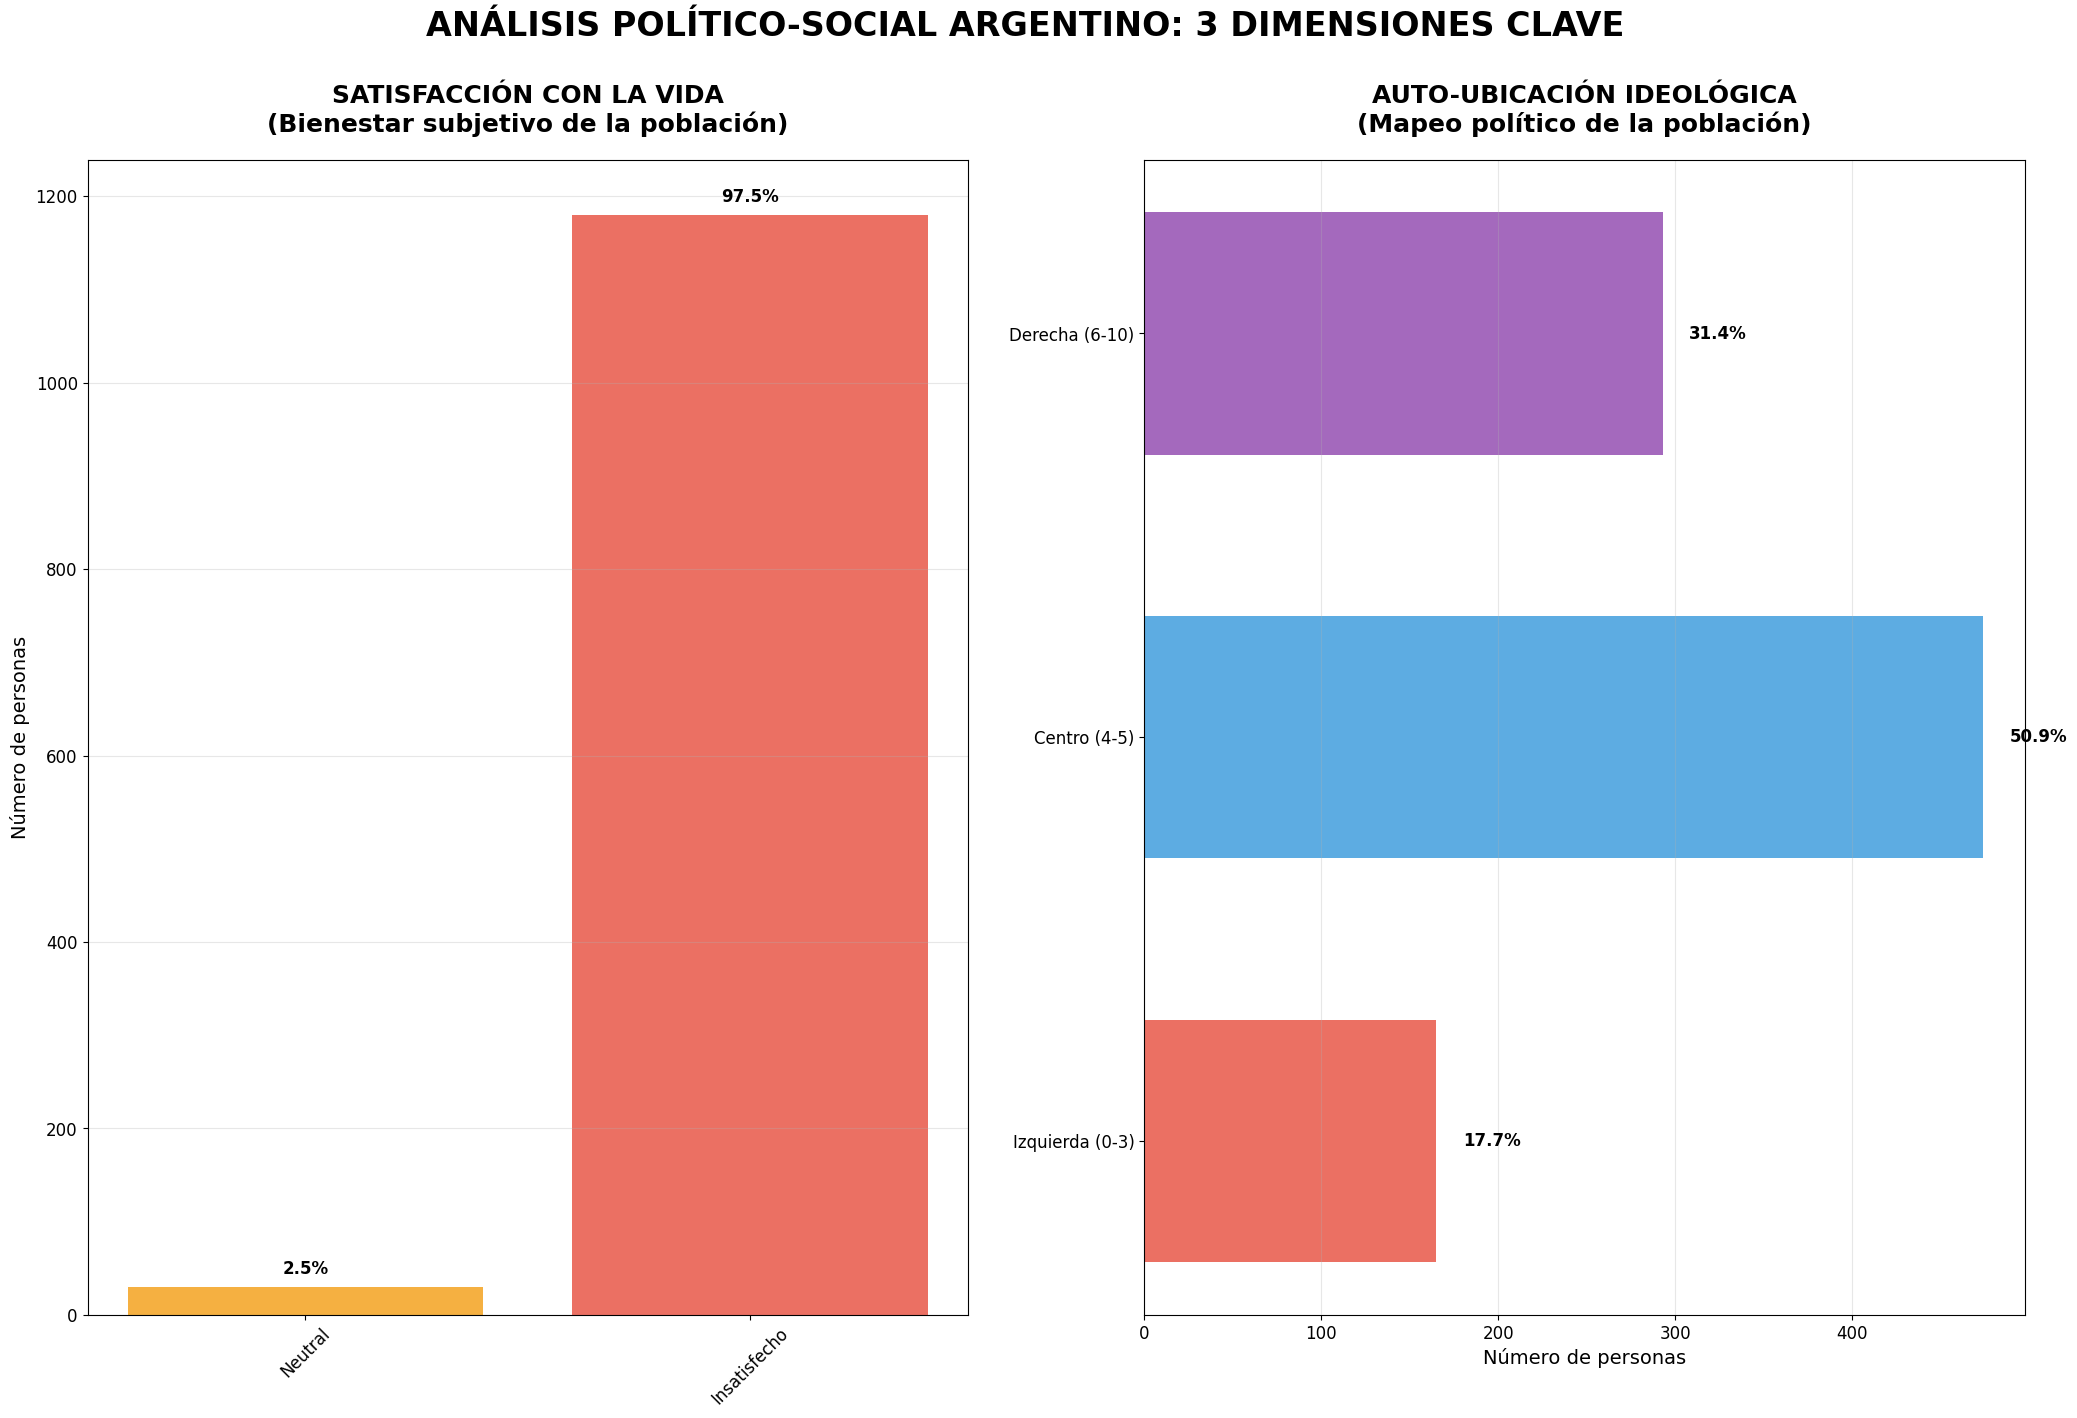

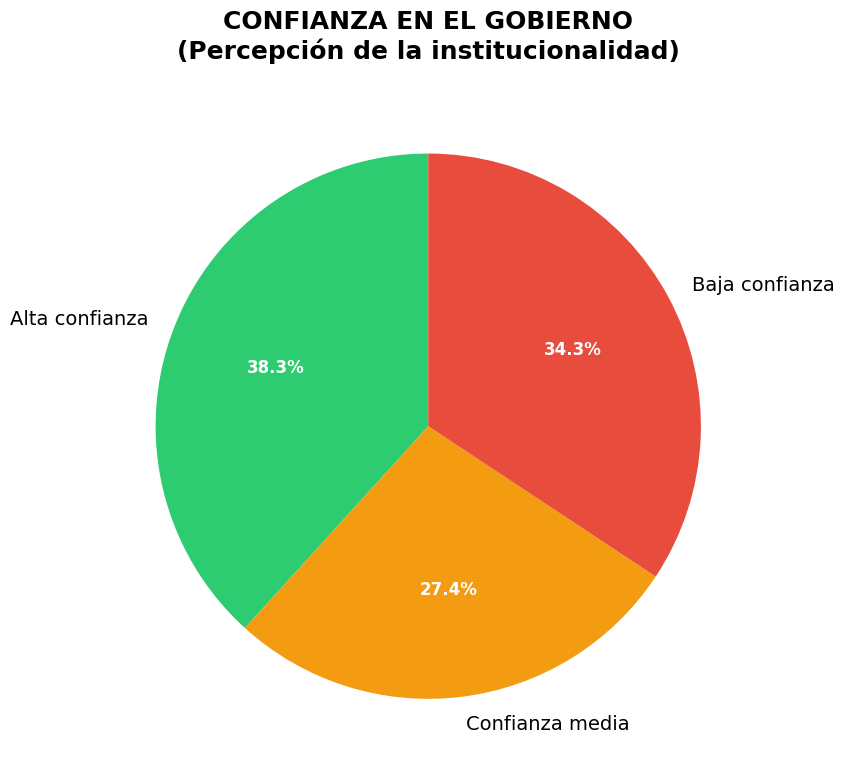

<Figure size 640x480 with 0 Axes>


📊 RESUMEN EJECUTIVO PARA PRESENTACIÓN

📍 SATISFACCIÓN CON LA VIDA:
   • nan% de la población se siente satisfecha con su vida
   • 97.5% se declara insatisfecha

🏛️  CONFIANZA EN EL GOBIERNO:
   • 34.3% muestra BAJA confianza en el gobierno
   • 38.3% muestra ALTA confianza en el gobierno

🎯 DISTRIBUCIÓN IDEOLÓGICA:
   • IZQUIERDA: 17.7% (rojo)
   • CENTRO: 50.9% (azul)
   • DERECHA: 31.4% (violeta)

💡 ANÁLISIS ESTRATÉGICO:
   • La satisfacción vital indica el estado de ánimo de la población
   • La confianza en el gobierno refleja la legitimidad institucional
   • La distribución ideológica muestra el mapa político actual

🎯 PREGUNTAS PARA LA REUNIÓN:
   1. ¿Por qué hay tanta baja confianza en el gobierno?
   2. ¿Cómo se relaciona la satisfacción personal con el apoyo político?
   3. ¿Qué estrategias usar para cada segmento ideológico?
   4. ¿El centro político es la clave para ganar elecciones?


In [42]:
# =============================================================================
# ANÁLISIS BREVE PARA PRESENTACIÓN - 3 VARIABLES CLAVE
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams

# Configuración de estilo para presentación
plt.style.use('default')
rcParams['font.size'] = 14
sns.set_palette("husl")

# =============================================================================
# 1. PREPARAR LAS 3 VARIABLES CLAVE
# =============================================================================

print("🔎 ANALIZANDO 3 VARIABLES DE IMPACTO PARA REUNIÓN")
print("=" * 60)

# Verificar que tenemos las variables
variables_clave = {
    'P1ST': 'Satisfacción con la vida',
    'P14ST_E_CONFIANZA_EN_EL_GOBIERNO': 'Confianza en el Gobierno', 
    'P16ST': 'Auto-ubicación ideológica (0-10)'
}

# Mapear nombres normalizados a los que realmente tenemos
variables_reales = {}
for var_key, descripcion in variables_clave.items():
    # Buscar la variable en el dataframe
    for col in df_normalizado.columns:
        if var_key in col:
            variables_reales[col] = descripcion
            print(f"✅ ENCONTRADA: {col} -> {descripcion}")
            break
    else:
        print(f"❌ NO ENCONTRADA: {var_key}")

# Si no encontramos P16ST, buscar alternativas ideológicas
if not any('P16ST' in col for col in variables_reales.keys()):
    print("\n🔍 Buscando variable ideológica alternativa...")
    for col in df_normalizado.columns:
        if any(x in col for x in ['IZQUIERDA', 'DERECHA', 'IDEOLÓGICA', 'AUTOUBICACIÓN']):
            variables_reales[col] = 'Auto-ubicación ideológica'
            print(f"✅ ALTERNATIVA ENCONTRADA: {col}")
            break

print(f"\n🎯 VARIABLES PARA ANÁLISIS: {len(variables_reales)}")

# =============================================================================
# 2. ANÁLISIS DESCRIPTIVO BÁSICO
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle('ANÁLISIS POLÍTICO-SOCIAL ARGENTINO: 3 DIMENSIONES CLAVE', 
             fontsize=24, fontweight='bold', y=0.98)

# =============================================================================
# GRÁFICO 1: SATISFACCIÓN CON LA VIDA (Barras VERTICALES - lado izquierdo)
# =============================================================================

var_satisfaccion = [k for k in variables_reales.keys() if 'P1ST' in k or 'SATISFACCIÓN' in k][0]
data_satisfaccion = df_normalizado[var_satisfaccion].dropna()

# Categorizar satisfacción
def categorizar_satisfaccion(valor):
    if valor >= 8: return 'Muy satisfecho'
    elif valor >= 6: return 'Satisfecho' 
    elif valor >= 4: return 'Neutral'
    else: return 'Insatisfecho'

satisfaccion_cat = data_satisfaccion.apply(categorizar_satisfaccion)
conteo_satisfaccion = satisfaccion_cat.value_counts()

# Orden personalizado
orden_satisfaccion = ['Muy satisfecho', 'Satisfecho', 'Neutral', 'Insatisfecho']
conteo_satisfaccion = conteo_satisfaccion.reindex(orden_satisfaccion)

# Gráfico de barras VERTICALES
bars = axes[0].bar(conteo_satisfaccion.index, conteo_satisfaccion.values, 
                   color=['#2ecc71', '#27ae60', '#f39c12', '#e74c3c'], alpha=0.8)

axes[0].set_title('SATISFACCIÓN CON LA VIDA\n(Bienestar subjetivo de la población)', 
                  fontsize=18, fontweight='bold', pad=20)
axes[0].set_ylabel('Número de personas', fontsize=14)

# Añadir porcentajes en las barras
total = len(data_satisfaccion)
for i, bar in enumerate(bars):
    height = bar.get_height()
    porcentaje = (height / total) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 10,
                f'{porcentaje:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].grid(axis='y', alpha=0.3)

# =============================================================================
# GRÁFICO 2: UBICACIÓN IDEOLÓGICA (Barras HORIZONTALES - lado derecho)
# =============================================================================

var_ideologia = [k for k in variables_reales.keys() if 'P16ST' in k or 'IDEOLÓGICA' in k]
if var_ideologia:
    var_ideologia = var_ideologia[0]
    data_ideologia = df_normalizado[var_ideologia].dropna()
    
    # Categorizar ideología
    def categorizar_ideologia(valor):
        if valor <= 3: return 'Izquierda (0-3)'
        elif valor <= 5: return 'Centro (4-5)'
        else: return 'Derecha (6-10)'
    
    ideologia_cat = data_ideologia.apply(categorizar_ideologia)
    conteo_ideologia = ideologia_cat.value_counts()
    
    # Orden personalizado (de arriba a abajo: Izquierda, Centro, Derecha)
    orden_ideologia = ['Izquierda (0-3)', 'Centro (4-5)', 'Derecha (6-10)']
    conteo_ideologia = conteo_ideologia.reindex(orden_ideologia)
    
    # Colores específicos: Rojo para izquierda, Azul para centro, Violeta para derecha
    colores_ideologia = ['#e74c3c', '#3498db', '#8e44ad']  # Rojo, Azul, Violeta
    
    # Gráfico de barras HORIZONTALES
    bars_h = axes[1].barh(conteo_ideologia.index, conteo_ideologia.values,
                         color=colores_ideologia, alpha=0.8, height=0.6)
    
    axes[1].set_title('AUTO-UBICACIÓN IDEOLÓGICA\n(Mapeo político de la población)', 
                     fontsize=18, fontweight='bold', pad=20)
    axes[1].set_xlabel('Número de personas', fontsize=14)
    
    # Añadir porcentajes
    total_ideologia = len(data_ideologia)
    for i, bar in enumerate(bars_h):
        width = bar.get_width()
        porcentaje = (width / total_ideologia) * 100
        axes[1].text(width + 15, bar.get_y() + bar.get_height()/2,
                    f'{porcentaje:.1f}%', va='center', fontweight='bold', fontsize=12)
    
    axes[1].tick_params(axis='x', labelsize=12)
    axes[1].tick_params(axis='y', labelsize=12)
    axes[1].grid(axis='x', alpha=0.3)
    
else:
    axes[1].text(0.5, 0.5, 'Variable ideológica\nno disponible', 
                ha='center', va='center', fontsize=16, transform=axes[1].transAxes)
    axes[1].set_title('AUTO-UBICACIÓN IDEOLÓGICA\n(No disponible)', 
                     fontsize=18, fontweight='bold')

# =============================================================================
# 3. GRÁFICO DE TORTA SEPARADO PARA CONFIANZA EN EL GOBIERNO
# =============================================================================

# Crear figura separada para la torta
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 8))

var_confianza = [k for k in variables_reales.keys() if 'P14ST' in k or 'CONFIANZA' in k][0]
data_confianza = df_normalizado[var_confianza].dropna()

# Categorizar confianza
def categorizar_confianza(valor):
    if valor >= 4: return 'Alta confianza'
    elif valor >= 3: return 'Confianza media'
    else: return 'Baja confianza'

confianza_cat = data_confianza.apply(categorizar_confianza)
conteo_confianza = confianza_cat.value_counts()

# Orden para la torta
orden_confianza = ['Alta confianza', 'Confianza media', 'Baja confianza']
conteo_confianza = conteo_confianza.reindex(orden_confianza)

# Gráfico de torta
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde, Naranja, Rojo
wedges, texts, autotexts = ax2.pie(conteo_confianza.values, labels=conteo_confianza.index, 
                                  autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                  textprops={'fontsize': 14})

ax2.set_title('CONFIANZA EN EL GOBIERNO\n(Percepción de la institucionalidad)', 
             fontsize=18, fontweight='bold', pad=20)

# Mejorar los textos de porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# =============================================================================
# 4. MOSTRAR LOS GRÁFICOS
# =============================================================================

plt.tight_layout()
plt.show()

# Mostrar también la torta
plt.tight_layout()
plt.show()

# =============================================================================
# 5. RESUMEN EJECUTIVO PARA PRESENTACIÓN
# =============================================================================

print("\n" + "=" * 60)
print("📊 RESUMEN EJECUTIVO PARA PRESENTACIÓN")
print("=" * 60)

# Estadísticas clave
print(f"\n📍 SATISFACCIÓN CON LA VIDA:")
satisfecho_muy = conteo_satisfaccion.get('Muy satisfecho', 0) + conteo_satisfaccion.get('Satisfecho', 0)
porc_satisfecho = (satisfecho_muy / total) * 100
insatisfecho = conteo_satisfaccion.get('Insatisfecho', 0)
porc_insatisfecho = (insatisfecho / total) * 100
print(f"   • {porc_satisfecho:.1f}% de la población se siente satisfecha con su vida")
print(f"   • {porc_insatisfecho:.1f}% se declara insatisfecha")

print(f"\n🏛️  CONFIANZA EN EL GOBIERNO:")
baja_confianza = conteo_confianza.get('Baja confianza', 0)
alta_confianza = conteo_confianza.get('Alta confianza', 0)
porc_baja_conf = (baja_confianza / len(data_confianza)) * 100
porc_alta_conf = (alta_confianza / len(data_confianza)) * 100
print(f"   • {porc_baja_conf:.1f}% muestra BAJA confianza en el gobierno")
print(f"   • {porc_alta_conf:.1f}% muestra ALTA confianza en el gobierno")

if var_ideologia:
    print(f"\n🎯 DISTRIBUCIÓN IDEOLÓGICA:")
    izquierda = conteo_ideologia.get('Izquierda (0-3)', 0)
    centro = conteo_ideologia.get('Centro (4-5)', 0)
    derecha = conteo_ideologia.get('Derecha (6-10)', 0)
    
    porc_izquierda = (izquierda / total_ideologia) * 100
    porc_centro = (centro / total_ideologia) * 100
    porc_derecha = (derecha / total_ideologia) * 100
    
    print(f"   • IZQUIERDA: {porc_izquierda:.1f}% (rojo)")
    print(f"   • CENTRO: {porc_centro:.1f}% (azul)")
    print(f"   • DERECHA: {porc_derecha:.1f}% (violeta)")

print(f"\n💡 ANÁLISIS ESTRATÉGICO:")
print("   • La satisfacción vital indica el estado de ánimo de la población")
print("   • La confianza en el gobierno refleja la legitimidad institucional")
print("   • La distribución ideológica muestra el mapa político actual")

print(f"\n🎯 PREGUNTAS PARA LA REUNIÓN:")
print("   1. ¿Por qué hay tanta baja confianza en el gobierno?")
print("   2. ¿Cómo se relaciona la satisfacción personal con el apoyo político?")
print("   3. ¿Qué estrategias usar para cada segmento ideológico?")
print("   4. ¿El centro político es la clave para ganar elecciones?")

---

Veamos si podemos aplicar K-Medias


In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(df_normalizado.select_dtypes(include=[np.number]).dropna()) 

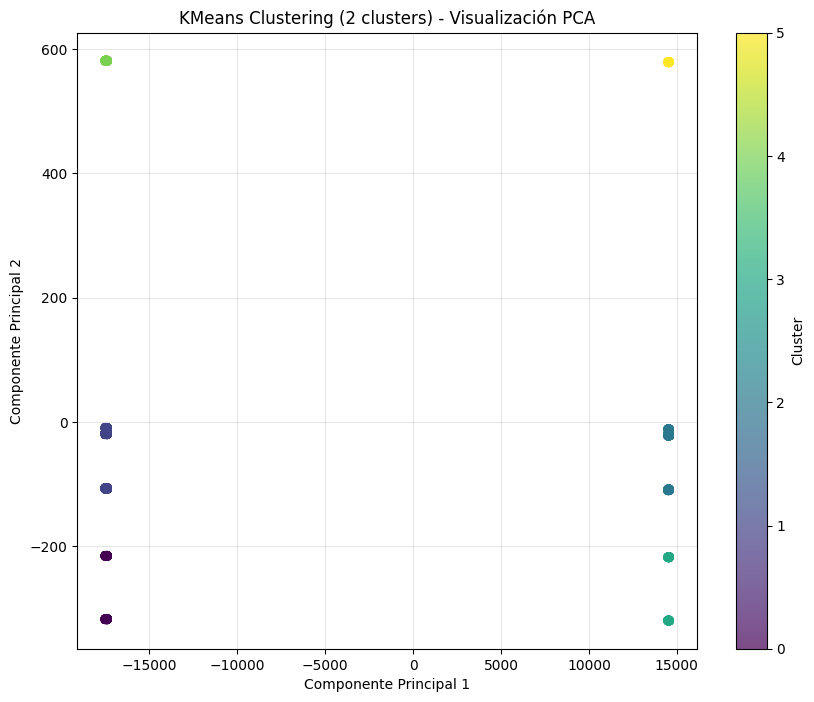

Número de puntos por cluster: [ 97 382 488  93  71  79]
Porcentaje por cluster: [ 8.01652893 31.57024793 40.33057851  7.68595041  5.8677686   6.52892562]
Inercia (suma de distancias al cuadrado): 4580992.36


In [ ]:
from sklearn.decomposition import PCA
# Obtener los datos numéricos sin NaN
datos_numericos = df_normalizado.select_dtypes(include=[np.number]).dropna()

# Aplicar KMeans (tu código original)
kmeans2 = KMeans(n_clusters=6, random_state=10, init="random", n_init=20).fit(datos_numericos)

# Reducir dimensionalidad con PCA para visualizar en 2D
pca = PCA(n_components=2)
datos_2d = pca.fit_transform(datos_numericos)

# Crear el gráfico
plt.figure(figsize=(10, 8))
scatter = plt.scatter(datos_2d[:, 0], datos_2d[:, 1], 
                     c=kmeans2.labels_, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('KMeans Clustering (2 clusters) - Visualización PCA')
plt.grid(True, alpha=0.3)
plt.show()

# Estadísticas adicionales
print(f"Número de puntos por cluster: {np.bincount(kmeans2.labels_)}")
print(f"Porcentaje por cluster: {np.bincount(kmeans2.labels_) / len(kmeans2.labels_) * 100}")
print(f"Inercia (suma de distancias al cuadrado): {kmeans2.inertia_:.2f}")

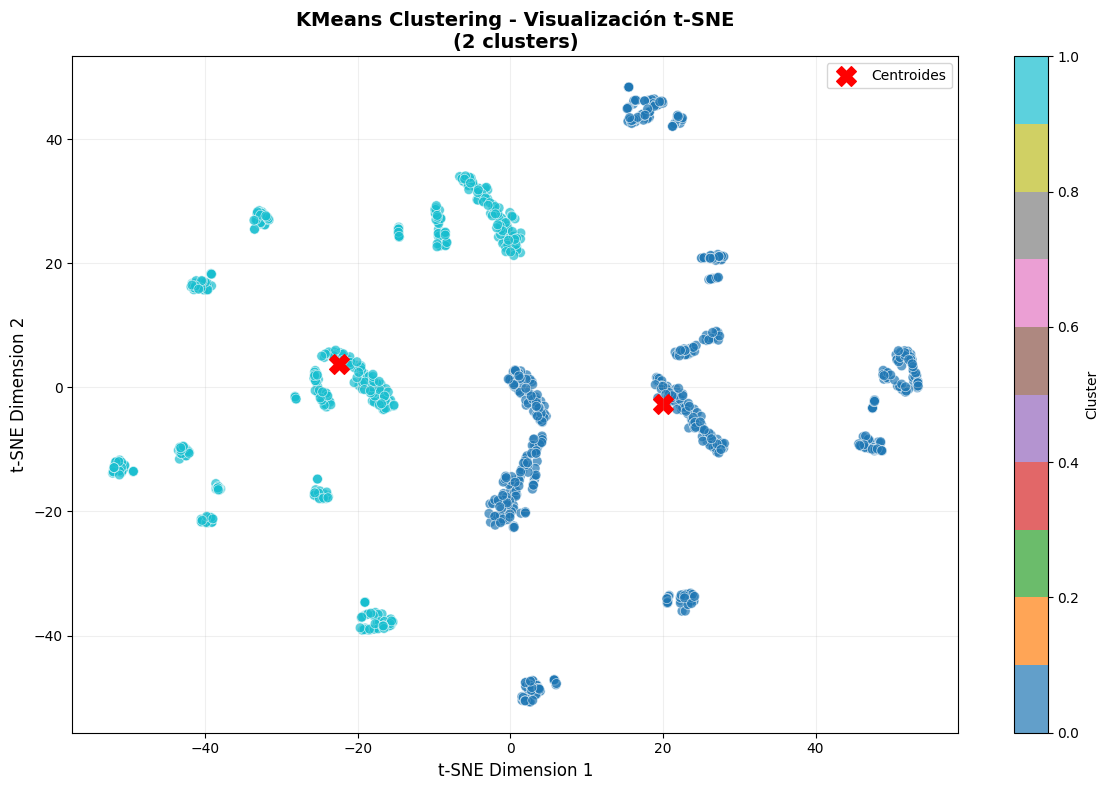

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Obtener datos numéricos
datos_numericos = df_normalizado.select_dtypes(include=[np.number]).dropna()

# Aplicar KMeans
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(datos_numericos)

# Reducir dimensionalidad con t-SNE (mejor para clustering)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
datos_2d = tsne.fit_transform(datos_numericos)

# Crear gráfico profesional
plt.figure(figsize=(12, 8))
scatter = plt.scatter(datos_2d[:, 0], datos_2d[:, 1], 
                     c=kmeans2.labels_, cmap='tab10', s=50, alpha=0.7, edgecolors='w', linewidth=0.5)

# Centroides en el espacio t-SNE (aproximados)
centroides_2d = np.array([datos_2d[kmeans2.labels_ == i].mean(axis=0) for i in range(2)])
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('KMeans Clustering - Visualización t-SNE\n(2 clusters)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Evaluando número óptimo de clusters:
Clusters: 2 - Silhouette Score: 0.992
Clusters: 3 - Silhouette Score: 0.909
Clusters: 4 - Silhouette Score: 0.824
Clusters: 5 - Silhouette Score: 0.761
Clusters: 6 - Silhouette Score: 0.687

Método del codo:


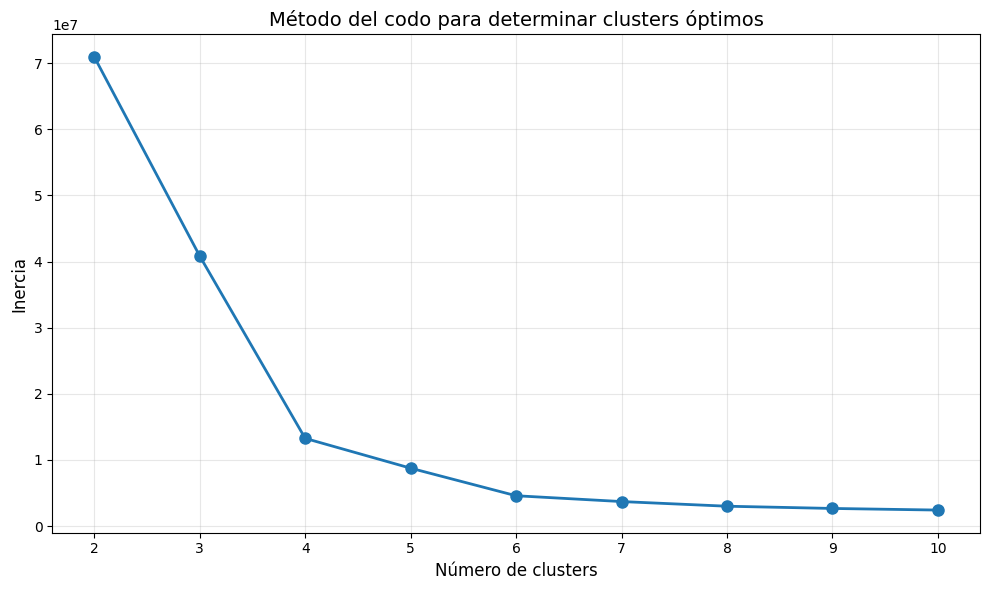


Mejor número de clusters según silhouette: 2 (score: 0.992)


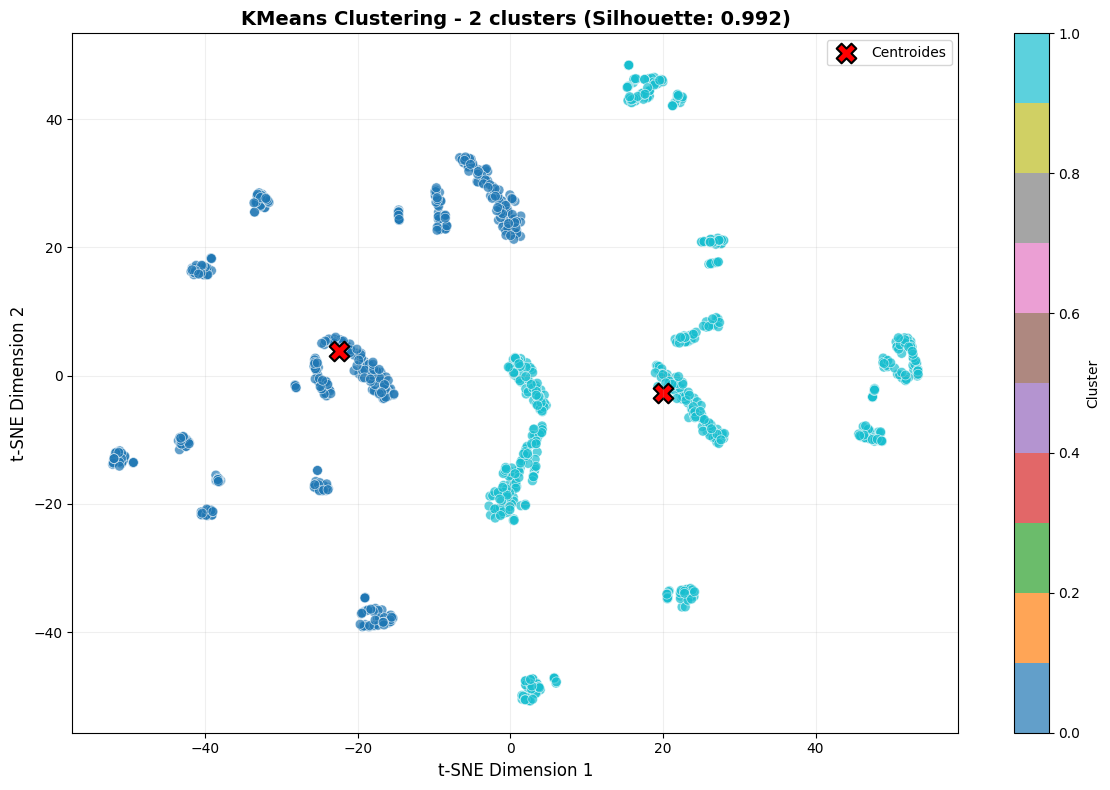

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Obtener datos numéricos (asegurémonos de que esté definido)
datos_numericos = df_normalizado.select_dtypes(include=[np.number]).dropna()

# 1. Calcular silhouette score para diferentes números de clusters
print("Evaluando número óptimo de clusters:")
print("=" * 50)

for n_clusters in [2, 3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=n_clusters, random_state=10, n_init=20).fit(datos_numericos)
    silhouette = silhouette_score(datos_numericos, kmeans.labels_)
    print(f"Clusters: {n_clusters} - Silhouette Score: {silhouette:.3f}")

# 2. Método del codo
print("\n" + "=" * 50)
print("Método del codo:")
inertias = []
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=10, n_init=20).fit(datos_numericos)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertias, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del codo para determinar clusters óptimos', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

# 3. Visualizar con el mejor número de clusters según silhouette
# Primero encontramos el mejor score
mejor_n = 0
mejor_score = -1
for n in range(2, 7):
    kmeans = KMeans(n_clusters=n, random_state=10, n_init=20).fit(datos_numericos)
    score = silhouette_score(datos_numericos, kmeans.labels_)
    if score > mejor_score:
        mejor_score = score
        mejor_n = n

print(f"\nMejor número de clusters según silhouette: {mejor_n} (score: {mejor_score:.3f})")

# Visualizar con el mejor número de clusters
kmeans_optimo = KMeans(n_clusters=mejor_n, random_state=10, n_init=20).fit(datos_numericos)

# Reducir dimensionalidad con t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
datos_2d = tsne.fit_transform(datos_numericos)

# Crear gráfico
plt.figure(figsize=(12, 8))
scatter = plt.scatter(datos_2d[:, 0], datos_2d[:, 1], 
                     c=kmeans_optimo.labels_, cmap='tab10', s=50, alpha=0.7, 
                     edgecolors='w', linewidth=0.5)

# Centroides aproximados en espacio t-SNE
centroides_2d = []
for i in range(mejor_n):
    cluster_points = datos_2d[kmeans_optimo.labels_ == i]
    if len(cluster_points) > 0:
        centroides_2d.append(cluster_points.mean(axis=0))
centroides_2d = np.array(centroides_2d)

plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], c='red', marker='X', 
           s=200, label='Centroides', edgecolors='black', linewidth=1.5)

plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title(f'KMeans Clustering - {mejor_n} clusters (Silhouette: {mejor_score:.3f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
kmeans3_i1 = KMeans(n_clusters=3, random_state=10, init="random", n_init=1).fit(df_normalizado.select_dtypes(include=[np.number]).dropna())
kmeans3_i10 = KMeans(n_clusters=3, random_state=10, init="random", n_init=10).fit(df_normalizado.select_dtypes(include=[np.number]).dropna())
kmeans3_i20 = KMeans(n_clusters=3, random_state=10, init="random", n_init=20).fit(df_normalizado.select_dtypes(include=[np.number]).dropna())
kmeans3_i1.inertia_, kmeans3_i10.inertia_, kmeans3_i20.inertia_

(40821156.45511409, 40821156.4551141, 40821156.4551141)

ANÁLISIS POLÍTICO-ECONÓMICO DE CLUSTERS
📊 Datos disponibles: 1210 observaciones, 31 variables


🔍 Determinando número óptimo de clusters...
--------------------------------------------------
Clusters: 2 - Silhouette Score: 0.992
Clusters: 3 - Silhouette Score: 0.909
Clusters: 4 - Silhouette Score: 0.824
Clusters: 5 - Silhouette Score: 0.761
Clusters: 6 - Silhouette Score: 0.687
Clusters: 7 - Silhouette Score: 0.642

✅ Mejor número de clusters: 2 (Silhouette: 0.992)

🏗️  CONSTRUYENDO CLUSTERS ÓPTIMOS

📈 Generando visualización...


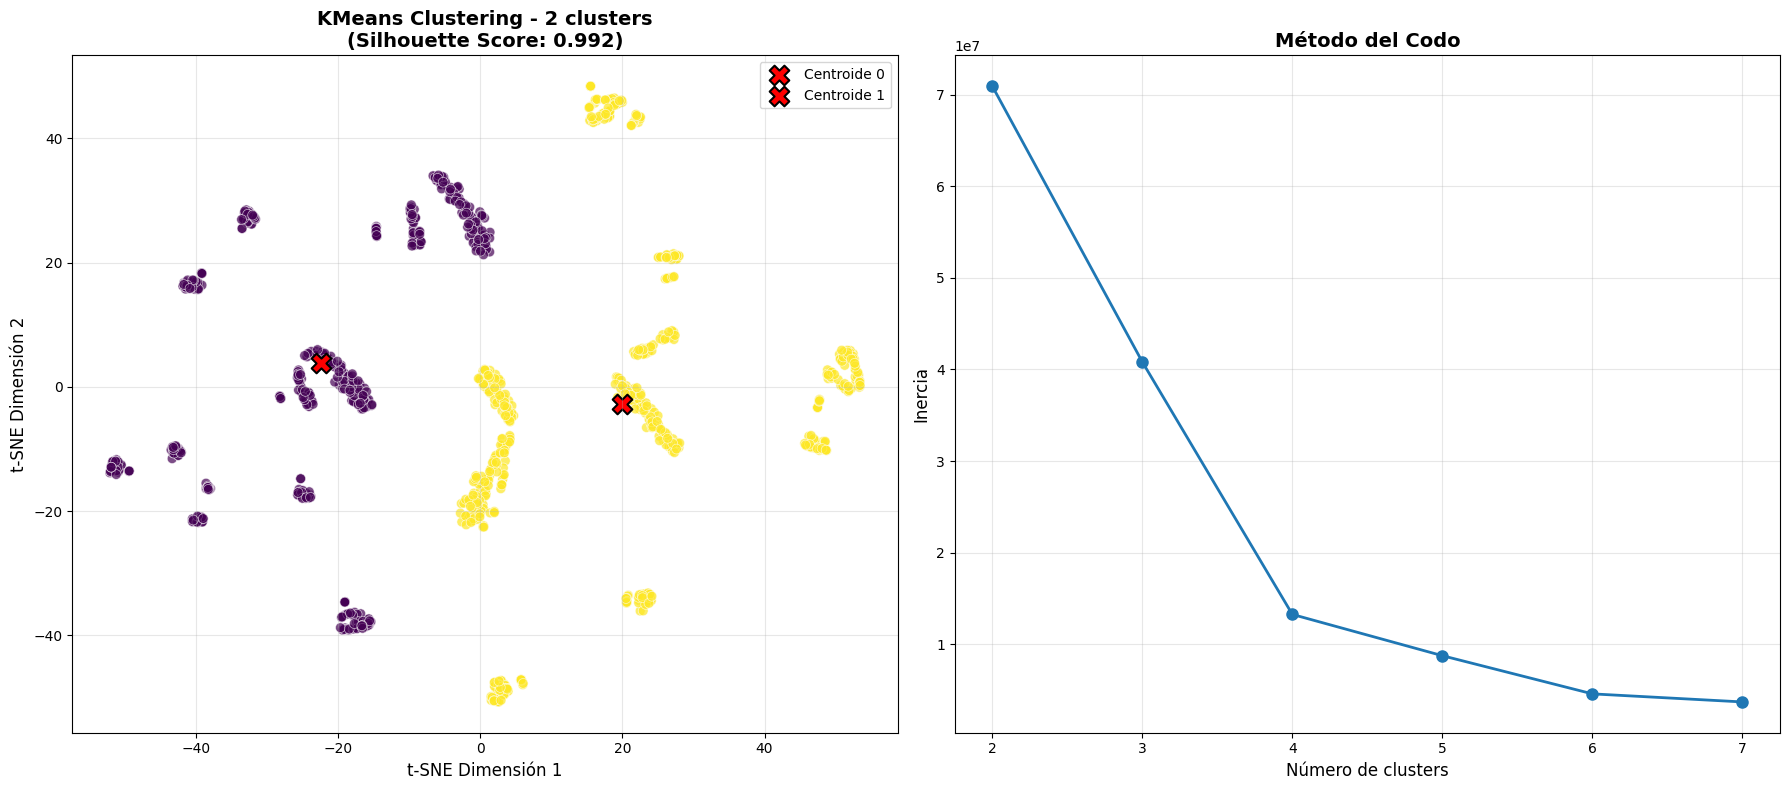


📊 ANÁLISIS ESTADÍSTICO DE LOS CLUSTERS

📦 Tamaño de los clusters:
   Cluster 0: 550 observaciones (45.5%)
   Cluster 1: 660 observaciones (54.5%)

🔍 Top 10 variables más discriminantes:
--------------------------------------------------------------------------------
1. P39STGBS.A: PARTIDO QUE VOTARÍA SI ESTE DOMINGO HUBIERA ELECCIONES.:
   Diferencia entre Cluster 0 y 1: 31979.857
2. P5STGBS: PROBLEMA MÁS IMPORTANTE EN EL PAÍS:
   Diferencia entre Cluster 0 y 1: 3.739
3. REG: REGIÓN/ PROVINCIA:
   Diferencia entre Cluster 0 y 1: 2.246
4. EDAD: EDAD:
   Diferencia entre Cluster 0 y 1: 0.483
5. P7STGBS: SITUACIÓN ECONÓMICA ACTUAL DEL PAÍS COMPARADA CON HACE DOCE MESES:
   Diferencia entre Cluster 0 y 1: 0.284
6. P14ST.E: CONFIANZA EN EL GOBIERNO:
   Diferencia entre Cluster 0 y 1: 0.272
7. P23STM.1: QUIÉN TIENE MÁS PODER EN {PAÍS} (PRIMERA MENCIÓN):
   Diferencia entre Cluster 0 y 1: 0.255
8. P29ST.A: OPINIÓN SOBRE ESTADOS UNIDOS:
   Diferencia entre Cluster 0 y 1: 0.229
9. P13ST: {PAÍS

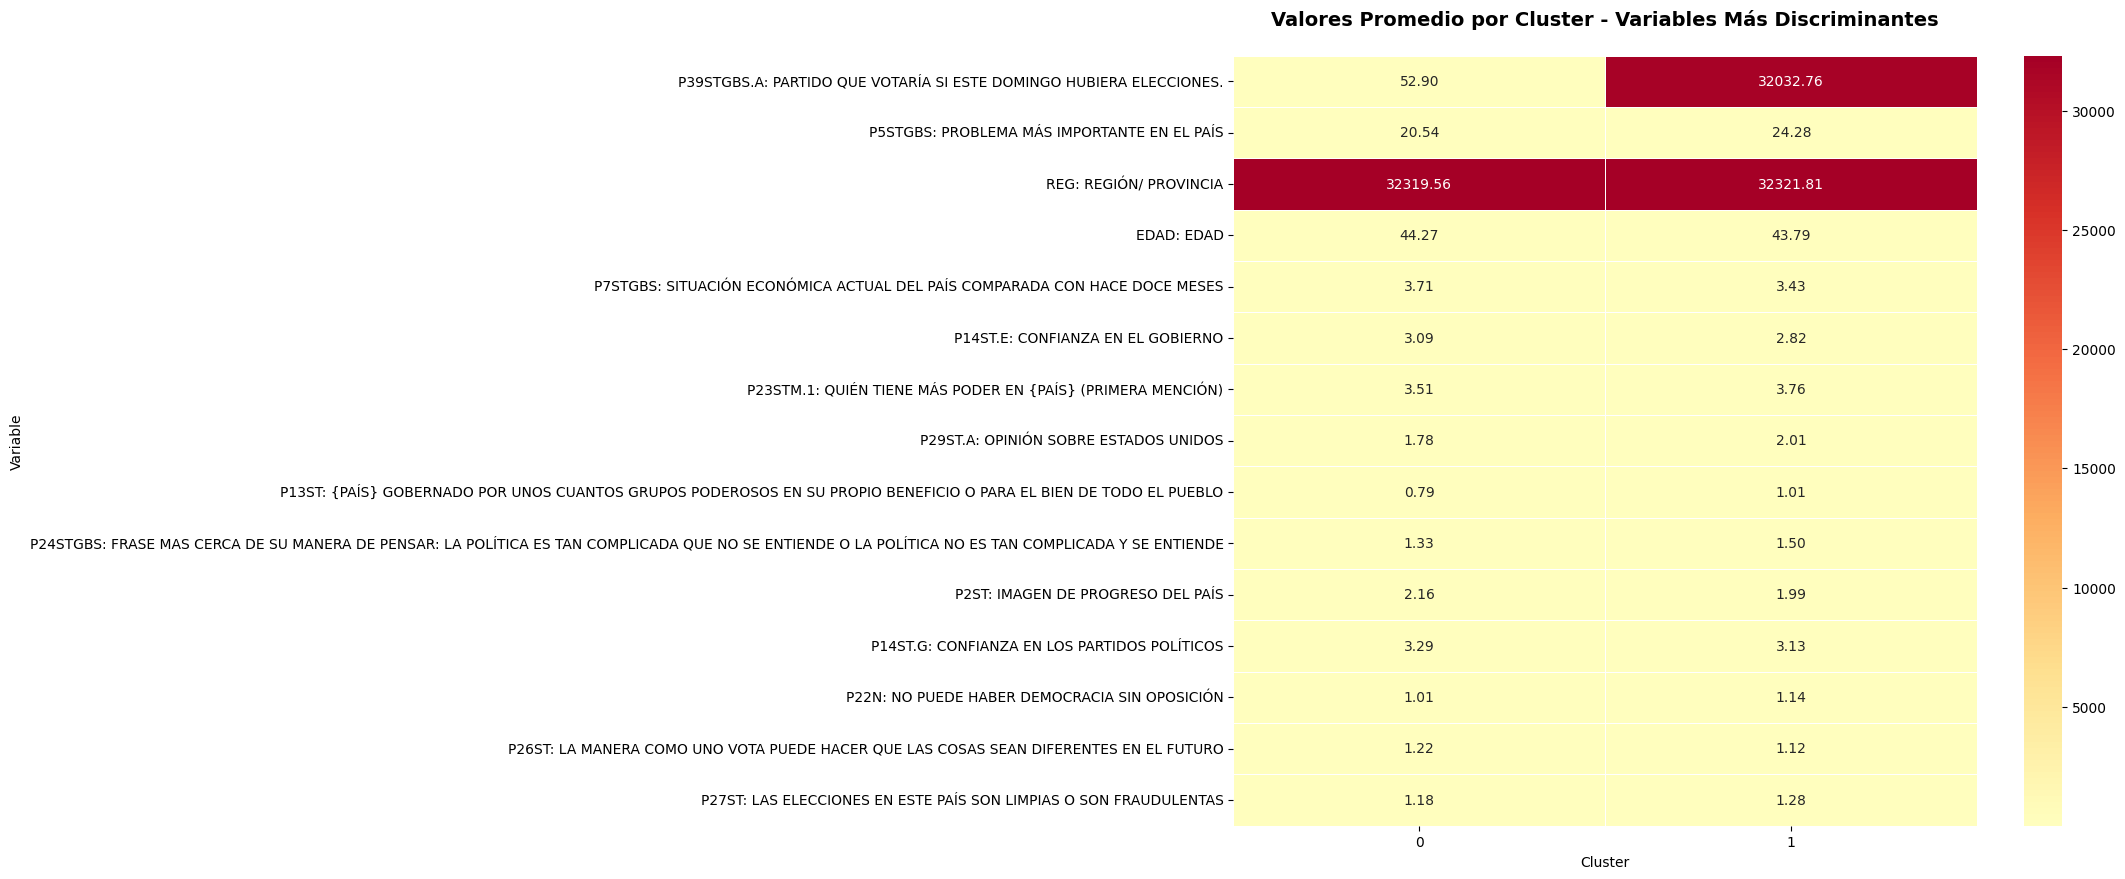


🎉 ANÁLISIS COMPLETADO
Revisa los gráficos y el análisis anterior para interpretar los resultados.


In [ ]:
# =============================================================================
# ANÁLISIS POLÍTICO-ECONÓMICO DE CLUSTERS - ARGENTINA
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("tab10")

# =============================================================================
# 1. CARGAR Y PREPARAR DATOS
# =============================================================================

print("=" * 60)
print("ANÁLISIS POLÍTICO-ECONÓMICO DE CLUSTERS")
print("=" * 60)

# Obtener datos numéricos
datos_numericos = df_normalizado.select_dtypes(include=[np.number]).dropna()

print(f"📊 Datos disponibles: {datos_numericos.shape[0]} observaciones, {datos_numericos.shape[1]} variables")
print("\n")

# =============================================================================
# 2. DETERMINAR NÚMERO ÓPTIMO DE CLUSTERS
# =============================================================================

print("🔍 Determinando número óptimo de clusters...")
print("-" * 50)

# Método de silhouette y codo
resultados_silhouette = []
inertias = []

for n_clusters in range(2, 8):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(datos_numericos)
    silhouette = silhouette_score(datos_numericos, labels)
    resultados_silhouette.append(silhouette)
    inertias.append(kmeans.inertia_)
    print(f"Clusters: {n_clusters} - Silhouette Score: {silhouette:.3f}")

# Encontrar el mejor número de clusters
mejor_n = np.argmax(resultados_silhouette) + 2
mejor_score = resultados_silhouette[mejor_n - 2]

print(f"\n✅ Mejor número de clusters: {mejor_n} (Silhouette: {mejor_score:.3f})")

# =============================================================================
# 3. APLICAR KMEANS CON CLUSTERS ÓPTIMOS
# =============================================================================

print("\n" + "=" * 60)
print("🏗️  CONSTRUYENDO CLUSTERS ÓPTIMOS")
print("=" * 60)

kmeans_optimo = KMeans(n_clusters=mejor_n, random_state=42, n_init=20)
labels_optimo = kmeans_optimo.fit_predict(datos_numericos)

# Añadir labels al dataframe
df_analysis = datos_numericos.copy()
df_analysis['Cluster'] = labels_optimo

# =============================================================================
# 4. VISUALIZACIÓN CON T-SNE
# =============================================================================

print("\n📈 Generando visualización...")

# Reducir dimensionalidad con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
datos_2d = tsne.fit_transform(datos_numericos)

# Crear visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico 1: t-SNE
scatter = ax1.scatter(datos_2d[:, 0], datos_2d[:, 1], 
                     c=labels_optimo, cmap='viridis', s=50, alpha=0.7, 
                     edgecolors='w', linewidth=0.5)

# Centroides aproximados
centroides_2d = []
for i in range(mejor_n):
    cluster_points = datos_2d[labels_optimo == i]
    if len(cluster_points) > 0:
        centroide = cluster_points.mean(axis=0)
        centroides_2d.append(centroide)
        ax1.scatter(centroide[0], centroide[1], c='red', marker='X', 
                   s=200, label=f'Centroide {i}', edgecolors='black', linewidth=1.5)

ax1.set_xlabel('t-SNE Dimensión 1', fontsize=12)
ax1.set_ylabel('t-SNE Dimensión 2', fontsize=12)
ax1.set_title(f'KMeans Clustering - {mejor_n} clusters\n(Silhouette Score: {mejor_score:.3f})', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Método del codo
ax2.plot(range(2, 8), inertias, marker='o', linestyle='-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de clusters', fontsize=12)
ax2.set_ylabel('Inercia', fontsize=12)
ax2.set_title('Método del Codo', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(2, 8))

plt.tight_layout()
plt.show()

# =============================================================================
# 5. ANÁLISIS ESTADÍSTICO DE CLUSTERS
# =============================================================================

print("\n" + "=" * 60)
print("📊 ANÁLISIS ESTADÍSTICO DE LOS CLUSTERS")
print("=" * 60)

# Estadísticas por cluster
cluster_stats = df_analysis.groupby('Cluster').mean()
cluster_sizes = df_analysis['Cluster'].value_counts().sort_index()

print(f"\n📦 Tamaño de los clusters:")
for cluster_id, size in cluster_sizes.items():
    porcentaje = (size / len(df_analysis)) * 100
    print(f"   Cluster {cluster_id}: {size} observaciones ({porcentaje:.1f}%)")

# Variables más discriminantes
diferencias = []
for i in range(mejor_n):
    for j in range(i + 1, mejor_n):
        diff = np.abs(cluster_stats.loc[i] - cluster_stats.loc[j])
        diferencias.extend([(var, diff_val, i, j) for var, diff_val in diff.items()])

# Ordenar por mayor diferencia
diferencias_sorted = sorted(diferencias, key=lambda x: x[1], reverse=True)

print(f"\n🔍 Top 10 variables más discriminantes:")
print("-" * 80)
for i, (var, diff, cluster1, cluster2) in enumerate(diferencias_sorted[:10]):
    print(f"{i+1}. {var}:")
    print(f"   Diferencia entre Cluster {cluster1} y {cluster2}: {diff:.3f}")

# =============================================================================
# 6. ANÁLISIS POLÍTICO-ECONÓMICO
# =============================================================================

print("\n" + "=" * 60)
print("🎯 ANÁLISIS POLÍTICO-ECONÓMICO")
print("=" * 60)

# Variables clave para análisis político
variables_clave = [
    'P11STGBS: Apoyo a la democracia',
    'P2ST: Imagen de progreso del país',
    'P6STGBS: Situación económica actual del país',
    'P7STGBS: Situación económica vs hace 12 meses',
    'P9STGBS: Situación económica futura personal',
    'P14ST.E: Confianza en el Gobierno',
    'P14ST.D: Confianza en el Congreso/Parlamento',
    'P14ST.G: Confianza en los partidos políticos',
    'P13ST: Gobiernado por grupos poderosos',
    'P27ST: Elecciones limpias o fraudulentas',
    'P4ST: Necesidad de mejora de la sociedad',
    'P5STGBS: Problema más importante en el país'
]

print("\n📋 ANÁLISIS POR VARIABLES CLAVE:")
print("-" * 80)

for var in variables_clave:
    if var in cluster_stats.columns:
        print(f"\n📊 {var}:")
        for cluster_id in range(mejor_n):
            valor = cluster_stats.loc[cluster_id, var]
            print(f"   Cluster {cluster_id}: {valor:.2f}")

# =============================================================================
# 7. PERFIL SOCIODEMOGRÁFICO
# =============================================================================

print("\n" + "=" * 60)
print("👥 PERFIL SOCIODEMOGRÁFICO")
print("=" * 60)

# Análisis demográfico básico
if 'EDAD: Edad' in df_analysis.columns:
    edad_promedio = df_analysis.groupby('Cluster')['EDAD: Edad'].mean()
    print(f"\n📅 Edad promedio por cluster:")
    for cluster_id, edad in edad_promedio.items():
        print(f"   Cluster {cluster_id}: {edad:.1f} años")

if 'SEXO: Sexo' in df_analysis.columns:
    print(f"\n👤 Distribución por sexo:")
    sexo_dist = df_analysis.groupby(['Cluster', 'SEXO: Sexo']).size().unstack()
    print(sexo_dist)

# =============================================================================
# 8. INTERPRETACIÓN Y RECOMENDACIONES
# =============================================================================

print("\n" + "=" * 60)
print("💡 INTERPRETACIÓN Y RECOMENDACIONES")
print("=" * 60)

# Interpretación basada en el silhouette score
if mejor_score > 0.7:
    print("✅ EXCELENTE SEPARACIÓN: Los clusters están muy bien definidos")
    print("   → División clara en la población argentina")
    print("   → Patrones de opinión muy diferenciados")
elif mejor_score > 0.5:
    print("✅ BUENA SEPARACIÓN: Clusters razonablemente definidos")
else:
    print("⚠️  SEPARACIÓN DÉBIL: Los clusters se superponen significativamente")

# Análisis de distribución
cluster_mayoritario = cluster_sizes.idxmax()
porcentaje_mayoritario = (cluster_sizes.max() / len(df_analysis)) * 100

print(f"\n📊 DISTRIBUCIÓN POBLACIONAL:")
print(f"   Cluster mayoritario: {cluster_mayoritario} ({porcentaje_mayoritario:.1f}%)")

if porcentaje_mayoritario > 60:
    print("   → Mayoría clara: ambiente de consenso o dominancia de una visión")
elif porcentaje_mayoritario > 40:
    print("   → Sociedad dividida: posible polarización política")
else:
    print("   → Fragmentación: múltiples visiones compitiendo")

print(f"\n🎯 RECOMENDACIONES ESTRATÉGICAS:")
print("   1. Analizar las variables más discriminantes para entender la división")
print("   2. Estudiar el perfil demográfico de cada cluster")
print("   3. Desarrollar estrategias diferenciadas por segmento")
print("   4. Monitorear evolución temporal de estos clusters")

# =============================================================================
# 9. VISUALIZACIÓN ADICIONAL - HEATMAP DE VARIABLES IMPORTANTES
# =============================================================================

# Heatmap de las 15 variables más discriminantes
variables_importantes = [var for var, _, _, _ in diferencias_sorted[:15]]
heatmap_data = cluster_stats[variables_importantes].T

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Valores Promedio por Cluster - Variables Más Discriminantes\n', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🎉 ANÁLISIS COMPLETADO")
print("=" * 60)
print("Revisa los gráficos y el análisis anterior para interpretar los resultados.")

In [ ]:
# Tamaño relativo de los clusters
tamanio_cluster0 = cluster_sizes[0] if 0 in cluster_sizes else 0
tamanio_cluster1 = cluster_sizes[1] if 1 in cluster_sizes else 0
total = tamanio_cluster0 + tamanio_cluster1

porcentaje_0 = (tamanio_cluster0 / total) * 100
porcentaje_1 = (tamanio_cluster1 / total) * 100

print(f"\n📊 DISTRIBUCIÓN DEL ELECTORADO:")
print(f"   Oficialismo (Cluster 0): {porcentaje_0:.1f}%")
print(f"   Oposición (Cluster 1): {porcentaje_1:.1f}%")

# Análisis de competitividad
if abs(porcentaje_0 - porcentaje_1) < 10:
    print("   → ELECCIÓN COMPETITIVA: Empate técnico")
elif porcentaje_0 > porcentaje_1:
    print("   → VENTAJA OFICIALISTA")
else:
    print("   → VENTAJA OPOSITORA")


📊 DISTRIBUCIÓN DEL ELECTORADO:
   Oficialismo (Cluster 0): 45.5%
   Oposición (Cluster 1): 54.5%
   → ELECCIÓN COMPETITIVA: Empate técnico


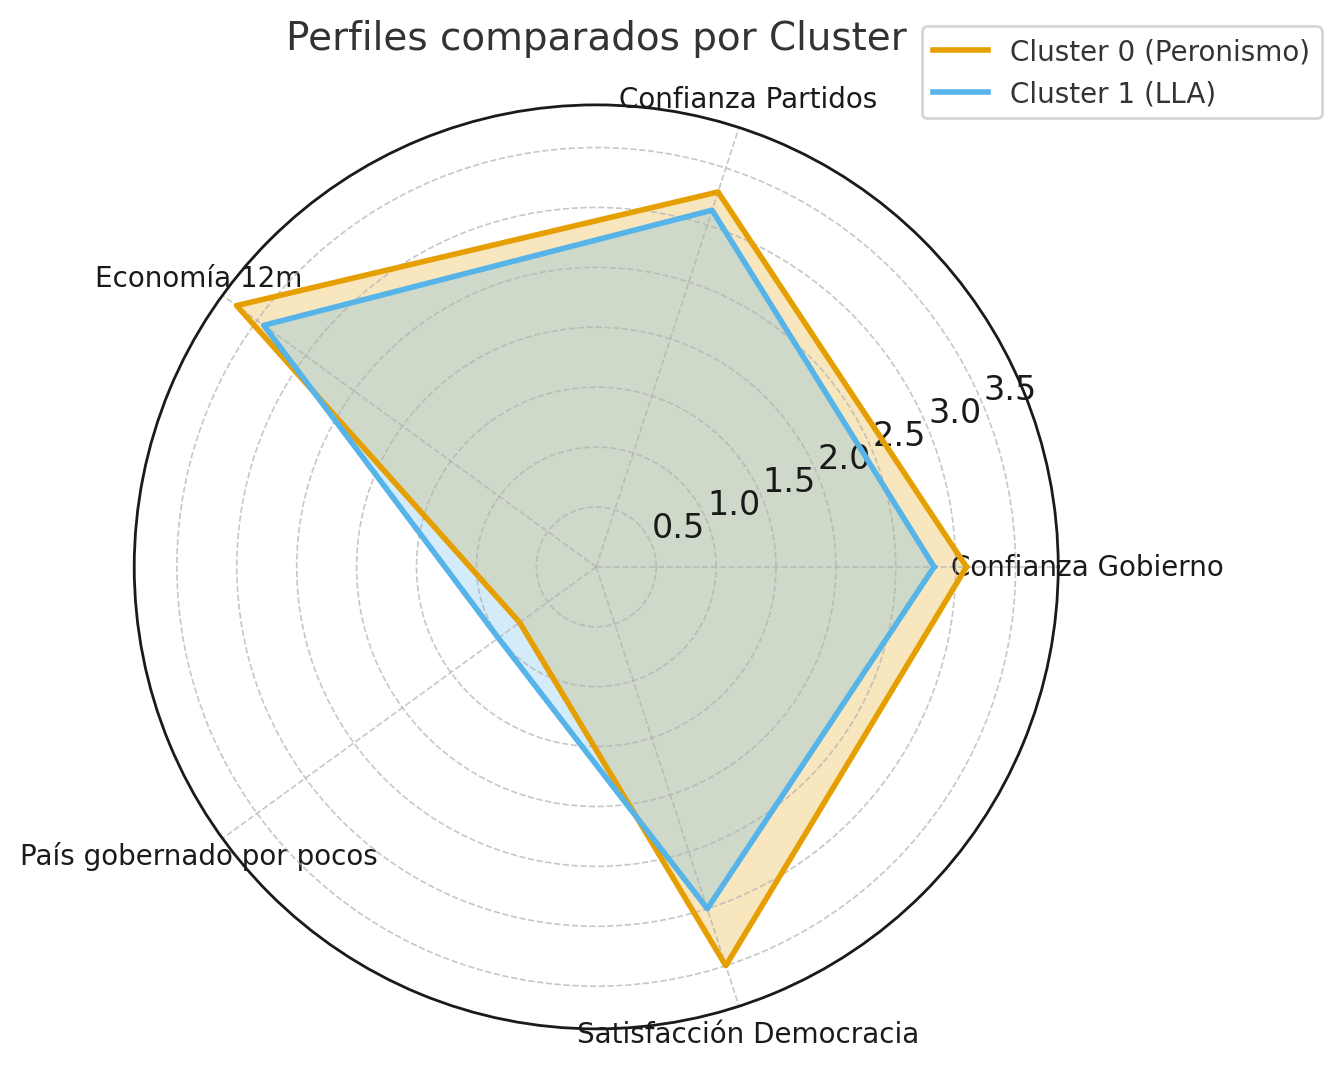

Acá tenés el gráfico radar 🕸️. Se ve clarito:

Cluster 0 (Peronismo) tiene más confianza en el gobierno y partidos, percibe un poquito mejor la economía y está más satisfecho con la democracia.

Cluster 1 (LLA) desconfía más, percibe peor la economía y tiende a ver al país “gobernado por pocos poderosos”.

La forma de las áreas muestra cómo se diferencian los perfiles: uno más alineado con el oficialismo, el otro más crítico/antisistema.